***Tests***

In [1]:
import importlib
import pytorch_optim
importlib.reload(pytorch_optim)
from pytorch_optim import *
import torch
import numpy as np
from scipy.optimize import minimize
from modele import *
from visualisation import *


In [2]:
N=5
nb_colonnes_default = 50
T = 300
L = 5 
P0 = torch.tensor([[0, 1 / 2, 1], [1 / 2, 0, 0], [1 / 2, 1 / 2, 0]]) 
params = {
    "N": N,  # nombre de couches
    "L": L,  # longueur du bassin
    "H": 1,  # hauteur du bassin
    "nb_colonnes_default": 50,  # discrétisation horizontale
    "D": 1e-5,  # coefficient de diffusion
    "T": T,  # temps final pour 20 tours
    "CFL": 0.95,  # facteur CFL
    "u" : [0.1]*N,
    "I_s": 1500,#1500 initialement
    "epsilon": 4.6, #4.6 initialement
    "k_d": 2.99e-4,   # 2.99*10e-5 = 2.99e-4
    "k_r": 4.8e-4,    # 4.8*10e-5 = 4.8e-4
    "k_h": 3.64e-4,   # 3.64*10e-5 = 3.64e-4
    "tau": 6.849,
    "sigma_H": 2.9e-3,  # 2.9*10e-4 = 2.9e-3
    "theta": 3.64e-4 * 2.9e-3,  # k_h * sigma_H
    "I_star": np.sqrt(4.8e-4 / (2.99e-4 * 6.849 * (2.9e-3)**2)),
    "mu_max": 3.64e-4 * 2.9e-3 / (6.849 * 2.9e-3 + 2*np.sqrt((2.99e-4 * 6.849 * (2.9e-3)**2)/4.8e-4))
}

In [3]:

meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params)
print(meilleure_masse, meilleure_matrice)

50.3962721912434 [[0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]]


In [32]:
P = np.array([
    [0., 1., 0., 0., 0.],
    [0., 0., 0., 1., 0.],
    [1., 0., 0., 0., 0.],
    [0., 0., 1., 0., 0.],
    [0., 0., 0., 0., 1.]
])
X, masse_par_couche = modèle_stochastique(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, P, params)

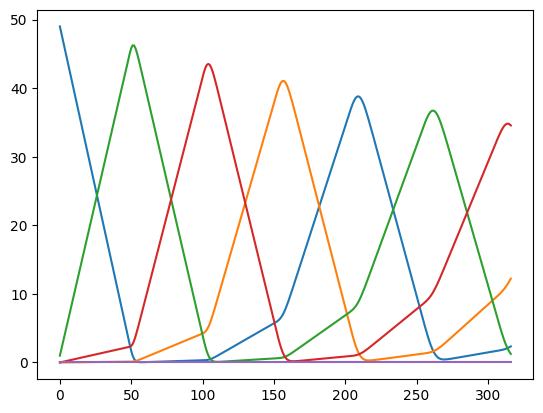

In [33]:
for L in masse_par_couche:
    plt.plot([k for k in range(len(L))], L)

In [30]:
fonction_objectif_optimize_test(X_ini_one_layer(N, nb_colonnes_default), T, np.array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0]), params)

50.38397182359854


np.float64(-50.38397182359854)

In [32]:
res = solve_optimize(X_ini_one_layer(N, nb_colonnes_default), T, params, np.array([0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0]))

50.38397182359854
50.38397333001698
50.3839728051602
50.383973315399544
50.383972617210794
50.38397333042599
50.38397280518328
50.38397331587117
50.38397261714885
50.383973331045524
50.383972805498516
50.38397331618829
50.38397261759043
50.383973329983554
50.383972805218264
50.383973315680755
50.38397261708233


In [33]:
res.x

array([0., 0., 0., 1., 0., 0., 1., 0., 1., 0., 0., 0., 0., 1., 0., 0.])

In [23]:
params["N"] = 6
params["u"] = [0.1]*6
meilleure_masse, meilleure_matrice, _ = meilleure_matrice_de_permutation(X_ini_one_layer(params["N"], params["nb_colonnes_default"]), T, params)
print(meilleure_masse, meilleure_matrice)

50.40865205914497 [[0. 0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]]


In [21]:
res = solve_optimize(X_ini_one_layer(6, nb_colonnes_default), T, params, matrix_to_vector(np.identity(6)))

50.21409768742719
50.2141024462869
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245245946
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245802246
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245985356
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245675546
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245071047
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.366202244588685
50.366204352027154
50.36620233085111
50.366203061106276
50.36620328650292
50.36620287613161
50.366202330831555
50.36620435223334
50.3662023308779
50.36620306133554
50.36620328679234
50.3662028763101
50.36620233085833
50.36620435458315
50.36620233092121
50.36620306193058
50.36620328757232
50.36620287676165
50.366202

In [22]:
print(res.x)

[ 6.48624530e-16  5.09658794e-17  3.52427184e-14 -1.75587448e-16
  1.00000000e+00 -4.60505851e-15 -3.88282433e-17  9.78619203e-01
 -3.24368212e-16 -2.74196419e-16  1.05866088e-16  2.13807974e-02
 -3.60667399e-15 -1.36192165e-17 -1.00089396e-13  1.00000000e+00
 -1.27782064e-14  7.91468631e-17  1.00000000e+00 -2.76184602e-17
  7.67537734e-17 -3.49719510e-15  3.04014519e-17  3.70878586e-17
 -6.73960601e-16 -1.15433501e-16  1.00000000e+00 -1.12609317e-13
  4.38936132e-14  4.63128134e-15 -2.27505664e-17  2.13807974e-02
  1.75454144e-16  4.51451593e-17  7.77445052e-18  9.78619203e-01]


In [34]:
params["N"] = 7
params["u"] = [0.1]*7
res = solve_optimize(X_ini_one_layer(7, nb_colonnes_default), T, params, matrix_to_vector(np.identity(7)))

50.21409768742719
50.2141024462869
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.214102451543
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245668753
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245967819
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410245907729
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.2141024551855
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21410244979946
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.21409768742719
50.37219629477076
50.372198267734774
50.37219637322126
50.37219683017578
50.3721972277213
50.37219715504

In [35]:
res.x

array([-2.48181721e-17,  9.76658579e-02,  8.97780602e-01,  1.22294782e-17,
       -3.74102689e-17,  7.85707762e-18,  4.55354000e-03,  1.23302757e-17,
        8.60707072e-01,  1.04262776e-17, -1.62988224e-17, -8.56723246e-18,
        1.02219398e-01,  3.70735302e-02,  1.82401800e-17, -2.64859157e-18,
       -8.08547211e-18,  2.76979774e-19,  1.00000000e+00,  1.37833410e-16,
        6.47589517e-18,  1.00000000e+00, -1.66536954e-17,  9.84358596e-17,
        1.23422230e-17,  2.00072263e-17, -1.98984216e-17, -1.11257067e-17,
        8.63989488e-17, -8.30118243e-18, -8.69251392e-18,  1.00000000e+00,
        3.00171536e-17, -1.64616618e-17, -7.36633163e-18, -2.67799487e-18,
       -2.44920418e-19,  1.02219398e-01, -2.49436998e-17, -1.56394046e-17,
        8.97780602e-01,  1.26629180e-17, -2.32145679e-17,  4.16270702e-02,
        1.62402833e-17,  2.40920046e-17, -1.82609879e-17,  4.36387745e-18,
        9.58372930e-01])

***Optimiser une fonction simple à deux paramètres.***

In [ ]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

f = (x - 5)**2 + (y - 2)**2 

optim = torch.optim.Adam([x, y], lr=0.001)

for k in range(20000):
    optim.zero_grad()
    f = (x - 5)**2 + (y - 2)**2 
    f.backward()
    optim.step()

print("x:", x.item(), "y:", y.item())

x: 5.0 y: 2.0


Maintenant, essayons d'optimiser cette fonction sur la courbe $y = x^2 - 1$.

In [ ]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(1.0, requires_grad=True)

optim = torch.optim.Adam([x, y], lr=0.01)
for p in range(10):
    epsilon = 10**(-p)
    for k in range(1000):
        optim.zero_grad()
        f = (x - 5)**2 + (y - 2)**2 + 1/epsilon*(x**2 - y - 1)**2 #pénalisation
        f.backward()
        optim.step()
    print(f'epsilon = {epsilon}' + ", x:", x.item(), "y:", y.item())

epsilon = 1, x: 2.094550371170044 y: 2.693570613861084
epsilon = 0.1, x: 1.9624724388122559 y: 2.7739076614379883
epsilon = 0.01, x: 1.9472311735153198 y: 2.7838704586029053
epsilon = 0.001, x: 1.9455440044403076 y: 2.7843570709228516
epsilon = 0.0001, x: 1.9440456628799438 y: 2.7792351245880127
epsilon = 1e-05, x: 1.9427201747894287 y: 2.774153470993042
epsilon = 1e-06, x: 1.9407801628112793 y: 2.7666268348693848
epsilon = 1e-07, x: 1.9390605688095093 y: 2.759956121444702
epsilon = 1e-08, x: 1.9372775554656982 y: 2.753044366836548
epsilon = 1e-09, x: 1.9372775554656982 y: 2.753044366836548


On remarque que quand la pénalité devient trop grande, le résultat s'éloigne de la solution (1.94, 2.78). Cela provient du fait que le rapport du gradient calculé et de la learning rate ***lr***  est trop important et empêche de converger vers le minimum. Nous devons adapter le choix de la learning rate à la valeur de $\epsilon$.

Pour mon problème de recherche des matrices de mélange, plusieurs possibilités : 
- résoudre équation de KKT en calculant les gradients par torch
- utiliser un solver (SLSQP, pulp ou autres) 
dans ce cas, choisir entre un problème sous contrainte, ou un problème relaxé avec pénalisation. 
- coder une descente de gradient à la main

a priori c'est la deuxième solution qui sera la meilleure, mais il reste à pouvoir utiliser pulp sur mes algorithmes, or ils ont pour arguments des entiers (nb_colonnes par exemple) donc non différentiables. De nombreuses reformulations du code à faire.

***Objective Function***

tests to see if the gradient is computed well :

In [ ]:
errors = test_gradient(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)
print(errors)

[tensor(-0.0450), tensor(-0.1042), tensor(0.1230), tensor(0.1698)]


L'approximation de la meilleure matrice de mélange est proche de celle recherchée : en effet, la biomasse étant uniquement présente initialement dans la couche 1, la meilleure matrice devrait déplacer cette couche en position 3.

In [6]:

P, biomass_list = solve(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)

up
0 50.34871292114258
1 50.403587341308594


KeyboardInterrupt: 

tensor([[4.6378e-03, 8.6861e-03, 4.0253e-04, 3.8210e-03, 2.6254e-03],
        [2.8638e-03, 6.8687e-03, 2.3584e-04, 2.3522e-03, 5.4945e-04],
        [8.8904e-01, 4.8527e-01, 9.9517e-01, 7.6708e-01, 9.9210e-01],
        [9.8167e-02, 4.8491e-01, 4.1068e-03, 2.1464e-01, 2.3730e-03],
        [5.2887e-03, 1.4267e-02, 7.9914e-05, 1.2107e-02, 2.3504e-03]],
       grad_fn=<SoftmaxBackward0>)


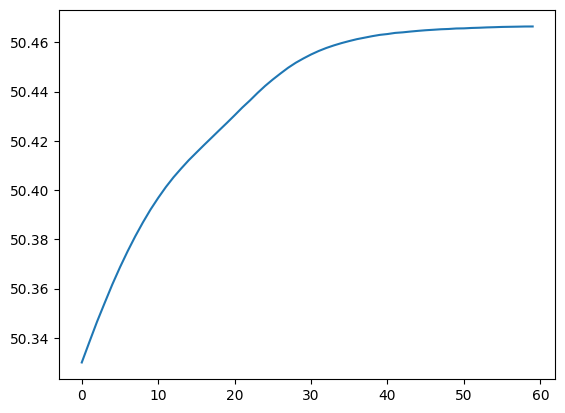

In [8]:
print(P)
plt.plot([k for k in range(60)], biomass_list)

In [4]:
print(params)

{'N': 10, 'L': 5, 'H': 1, 'nb_colonnes_default': 50, 'D': 1e-05, 'T': 300, 'CFL': 0.95, 'u': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], 'I_s': 1500, 'epsilon': 4.6, 'k_d': 0.000299, 'k_r': 0.00048, 'k_h': 0.000364, 'tau': 6.849, 'sigma_H': 0.0029, 'theta': 1.0556e-06, 'I_star': np.float64(166.94501039780602), 'mu_max': np.float64(3.315108749636504e-05)}


In [6]:
params["u"] = [0.1]*10
params["N"] = 10
T = 300
P_, biomass_list_ = solve(X_ini_one_layer_torch(10, nb_colonnes_default), T, params)

0 50.3839111328125
1 50.39091491699219
2 50.39757537841797
3 50.403724670410156
4 50.40940475463867
5 50.41470718383789
6 50.41950988769531
7 50.42387390136719
8 50.42775344848633
9 50.431312561035156
10 50.434452056884766
11 50.43731689453125
12 50.43978500366211
13 50.44199752807617
14 50.44392395019531
15 50.44573211669922
16 50.44725036621094
17 50.44868469238281
18 50.45002365112305
19 50.451175689697266
20 50.45233154296875
21 50.45343780517578
22 50.454551696777344
23 50.45552062988281
24 50.45664596557617
25 50.457611083984375
26 50.45854187011719
27 50.4594612121582
28 50.46036911010742
29 50.461273193359375
30 50.462196350097656
31 50.46300506591797
32 50.463897705078125
33 50.46480941772461
34 50.46566390991211


tensor([[2.1424e-03, 3.7470e-03, 6.8159e-03, 1.5721e-03, 3.7020e-04, 7.4651e-04,
         3.9078e-04, 2.1669e-03, 2.6406e-03, 1.0930e-02],
        [1.1297e-03, 1.1958e-03, 2.6421e-03, 1.0810e-03, 7.7419e-04, 6.3588e-04,
         3.4887e-03, 9.6978e-04, 3.0403e-03, 2.0210e-03],
        [1.8342e-03, 1.3635e-03, 1.3405e-03, 1.3935e-03, 1.4375e-04, 1.2462e-03,
         3.6479e-04, 1.6936e-03, 1.6688e-02, 9.0650e-03],
        [1.0258e-02, 7.4529e-02, 4.5789e-02, 5.5644e-03, 9.8920e-03, 6.6605e-02,
         6.0155e-02, 5.7467e-02, 1.9177e-01, 6.3572e-02],
        [5.8903e-01, 4.7396e-02, 6.4137e-02, 4.8106e-01, 1.2025e-01, 1.3755e-01,
         1.0727e-01, 6.3727e-01, 2.9535e-01, 2.4104e-01],
        [3.6863e-01, 5.5150e-01, 7.4337e-01, 4.5506e-01, 3.4619e-01, 5.5197e-01,
         7.2074e-01, 2.4961e-01, 4.5882e-02, 4.4709e-01],
        [2.2724e-02, 3.0688e-01, 5.5133e-02, 4.8790e-02, 5.1229e-01, 2.3708e-01,
         1.0061e-01, 2.6947e-02, 3.1256e-01, 1.2234e-01],
        [2.5314e-03, 3.1957

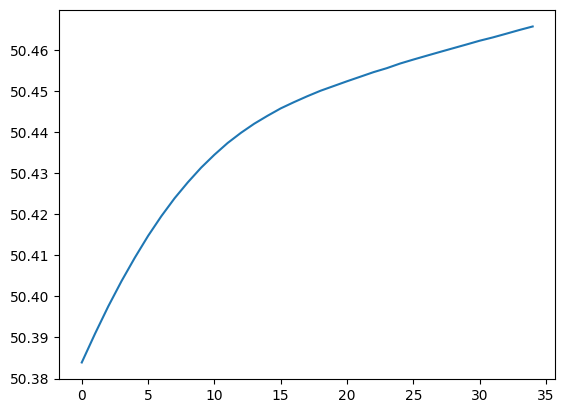

In [9]:
print(P_)
plt.plot([k for k in range(35)], biomass_list_)

In [3]:
params["u"] = [0.1]*20
params["N"] = 20
T = 300
P_20, biomass_list_20 = solve(X_ini_one_layer_torch(20, nb_colonnes_default), T, params)

0 50.36395263671875
1 50.3717041015625
2 50.37909698486328
3 50.38614273071289
4 50.392662048339844
5 50.39882278442383
6 50.40452575683594
7 50.409828186035156
8 50.41477584838867
9 50.419281005859375
10 50.423370361328125
11 50.427066802978516
12 50.430442810058594
13 50.43341827392578
14 50.43609619140625
15 50.43852996826172
16 50.44081115722656
17 50.44285583496094
18 50.444732666015625
19 50.446441650390625
20 50.44809341430664
21 50.44959259033203
22 50.45100021362305
23 50.45233154296875
24 50.4536247253418
25 50.454959869384766
26 50.45612335205078
27 50.45726013183594
28 50.45830154418945
29 50.45949935913086
30 50.46061325073242
31 50.46169662475586
32 50.46265411376953
33 50.4637336730957
34 50.46471405029297


tensor([[1.1427e-03, 1.9156e-03, 2.2509e-03, 2.1406e-03, 1.5372e-03, 1.2185e-03,
         8.4926e-04, 5.3591e-04, 4.8110e-04, 1.6607e-04, 3.0377e-04, 4.9521e-03,
         9.5927e-04, 4.0801e-04, 4.1795e-04, 2.9146e-03, 5.2093e-03, 6.8853e-03,
         1.7521e-02, 1.7326e-03],
        [4.9483e-03, 6.1887e-03, 4.8524e-03, 1.9977e-03, 9.4385e-03, 9.4021e-04,
         2.2423e-03, 4.9520e-04, 1.3265e-04, 2.4723e-04, 1.6795e-04, 3.6510e-04,
         5.6368e-04, 1.6309e-04, 4.6010e-04, 4.2356e-04, 2.5777e-03, 4.2709e-03,
         1.9225e-03, 1.0826e-03],
        [1.6059e-04, 2.3709e-03, 4.0244e-04, 8.8233e-04, 1.2488e-03, 7.5863e-04,
         4.6894e-04, 2.7740e-04, 8.7529e-05, 1.4258e-04, 7.8278e-04, 5.3651e-04,
         1.6121e-04, 6.1356e-04, 3.2966e-04, 7.6904e-04, 6.3528e-04, 5.9400e-03,
         9.4666e-04, 7.6786e-04],
        [3.3949e-04, 1.4379e-03, 5.2698e-04, 2.6029e-03, 2.9841e-03, 2.1810e-03,
         1.0685e-03, 4.6197e-04, 1.1677e-03, 1.4715e-04, 5.2394e-04, 2.4117e-04,
       

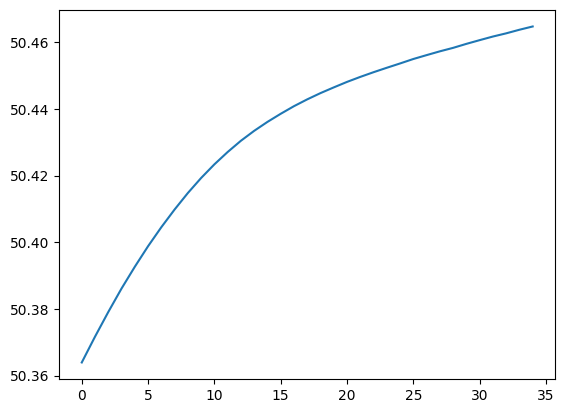

In [4]:
print(P_20)
plt.plot([k for k in range(35)], biomass_list_20)

In [ ]:
T = 300
P, biomass_list = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params)


0 50.25628662109375
50 50.30965805053711
100 50.310272216796875


In [ ]:
print(P_)
print(biomass_list_)

tensor([[1.4041e-04, 2.8473e-03, 9.5556e-03, 2.0696e-04, 4.9693e-05, 1.8973e-04,
         5.6439e-04, 9.8612e-04, 1.1707e-03, 4.3672e-03],
        [6.5824e-05, 1.0563e-02, 1.1407e-03, 2.0222e-02, 3.3707e-04, 9.2370e-05,
         4.0554e-04, 7.1372e-03, 3.5983e-03, 6.2287e-03],
        [4.4433e-05, 9.4903e-03, 7.8348e-03, 3.4995e-03, 4.2907e-04, 5.5270e-05,
         2.5133e-04, 4.7080e-03, 4.2107e-03, 3.6368e-03],
        [7.0800e-04, 3.9395e-01, 3.7324e-01, 7.9597e-02, 1.2770e-04, 5.7395e-05,
         2.1784e-03, 1.1173e-01, 1.5130e-01, 8.2463e-02],
        [3.0304e-03, 2.8465e-01, 2.5055e-01, 7.1804e-02, 1.1742e-02, 4.4724e-04,
         5.0396e-01, 7.3372e-02, 1.9280e-01, 5.1491e-02],
        [9.9245e-01, 9.4936e-02, 7.5642e-02, 4.4277e-01, 9.8530e-01, 9.9889e-01,
         3.4541e-01, 5.1129e-01, 3.3142e-01, 5.9903e-01],
        [3.1089e-03, 8.6923e-02, 1.3955e-01, 3.7092e-01, 1.0411e-03, 7.4332e-05,
         1.4160e-01, 2.8273e-01, 2.6762e-01, 2.0348e-01],
        [1.0636e-04, 1.0268

: 

La matrice de permutation donne un meilleur rendement ... Et si on recommence le calcul, mais en partant d'une matrice très proche de cette matrice de permutation ?

In [3]:
P_new, biomass_list_new = solve(X_ini_one_layer_torch(5, nb_colonnes_default), T, params,
                                True, [[-1e16, -1e16, -1e16, -1e16, 0], 
                                      [-1e16, -1e16, -1e16, 0, -1e16],
                                      [0, -1e16, -1e16, -1e16, -1e16],
                                      [-1e16, -1e16, 0, -1e16, -1e16],
                                      [-1e16, 0, -1e16, -1e16, -1e16]])



RuntimeError: The size of tensor a (3) must match the size of tensor b (5) at non-singleton dimension 0

In [ ]:
print(P_new)
print(biomass_list_new)
Q_new = P_new.detach()
fonction_objectif(X_ini_one_layer_torch(5, nb_colonnes_default), T, Q_new, params)

tensor([[4.2511e-04, 1.1178e-02, 1.5017e-04, 9.4955e-04, 1.1094e-02],
        [2.4318e-04, 7.2756e-03, 1.0117e-04, 6.9247e-04, 7.1234e-03],
        [9.8735e-01, 5.4983e-01, 9.9605e-01, 9.4107e-01, 5.5555e-01],
        [1.1666e-02, 4.2256e-01, 3.5786e-03, 5.6507e-02, 4.1718e-01],
        [3.1183e-04, 9.1527e-03, 1.1774e-04, 7.7707e-04, 9.0435e-03]],
       grad_fn=<SoftmaxBackward0>)
[50.27333068847656, 50.27613830566406, 50.278987884521484, 50.281829833984375, 50.28462219238281, 50.28730010986328, 50.289833068847656, 50.29216384887695, 50.294281005859375, 50.29617691040039, 50.29784393310547, 50.29928207397461, 50.30052947998047, 50.30158615112305, 50.30248260498047, 50.303245544433594, 50.30388641357422, 50.30443572998047, 50.30490493774414, 50.30530548095703, 50.30565643310547, 50.30596160888672, 50.306236267089844, 50.30647277832031, 50.30669021606445, 50.30689239501953, 50.30707550048828, 50.3072509765625, 50.30740737915039, 50.30756378173828, 50.307708740234375, 50.3078498840332, 

np.float32(50.310562)

In [3]:

P, biomass_list = solve(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)
print(f'P : {P}')
print(f'biomass list : {biomass_list}')
X = X_ini_one_layer(N, nb_colonnes_default)
masse_totale, M, liste_biomasses= meilleure_matrice_de_permutation(X, T, params)
print(f'best permutation matrix : {M}')
print(f'masse totale : {masse_totale}')

NameError: name 'solve' is not defined

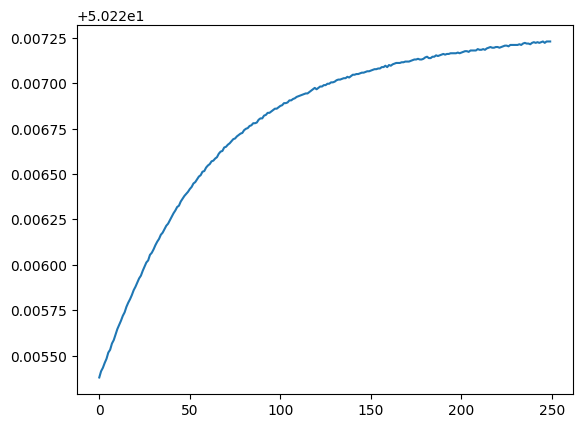

In [ ]:
plt.plot([k for k in range(250)], biomass_list)

In [ ]:
print(P)

tensor([[0.0186, 0.1844, 0.0070],
        [0.0078, 0.0743, 0.0179],
        [0.9736, 0.7413, 0.9751]], grad_fn=<SoftmaxBackward0>)


In [ ]:
lrs, losses = lr_finder(X_ini_one_layer_torch(N, nb_colonnes_default), T, params)

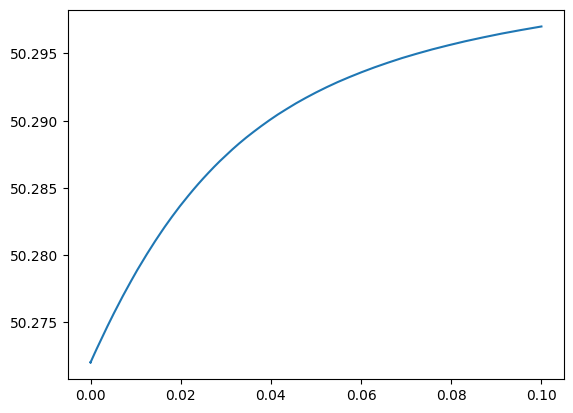

In [ ]:
plt.plot(lrs, losses)

Methode de Newton

In [ ]:
N_lignes = params["N"]
Q = torch.nn.Parameter(torch.randn(N_lignes, N_lignes))
def J(Q):
    P = torch.softmax(Q, dim=0)
    return(fonction_objectif_torch(X_ini_one_layer_torch(N_lignes, nb_colonnes_default), T, P, params))

Q_sol, masse_tot_max = Newton(J, Q)
print(torch.softmax(Q_sol, dim=0))
print(f'masse finale : {masse_tot_max}')

Pour des matrices bistochastiques

obj: tensor(50.3747, grad_fn=<AddBackward0>) pen: tensor(0.3211, grad_fn=<SumBackward0>)
obj: tensor(50.3718, grad_fn=<AddBackward0>) pen: tensor(0.1321, grad_fn=<SumBackward0>)
obj: tensor(50.3710, grad_fn=<AddBackward0>) pen: tensor(0.0467, grad_fn=<SumBackward0>)
obj: tensor(50.3704, grad_fn=<AddBackward0>) pen: tensor(0.0235, grad_fn=<SumBackward0>)
obj: tensor(50.3705, grad_fn=<AddBackward0>) pen: tensor(0.0706, grad_fn=<SumBackward0>)
obj: tensor(50.3711, grad_fn=<AddBackward0>) pen: tensor(0.1002, grad_fn=<SumBackward0>)
obj: tensor(50.3720, grad_fn=<AddBackward0>) pen: tensor(0.0790, grad_fn=<SumBackward0>)
obj: tensor(50.3726, grad_fn=<AddBackward0>) pen: tensor(0.0380, grad_fn=<SumBackward0>)
obj: tensor(50.3731, grad_fn=<AddBackward0>) pen: tensor(0.0092, grad_fn=<SumBackward0>)
obj: tensor(50.3730, grad_fn=<AddBackward0>) pen: tensor(0.0043, grad_fn=<SumBackward0>)
obj: tensor(50.3725, grad_fn=<AddBackward0>) pen: tensor(0.0161, grad_fn=<SumBackward0>)
obj: tensor(50.3717, 

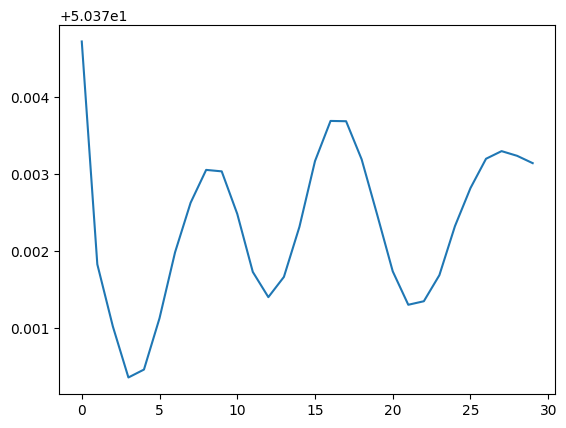

In [15]:
#d'abord pour 5 lignes
params["N"] = 5
params["u"] = [0.1]*5

P_bisto_5, biomass_list_bisto_5 = solve_bistochastique(X_ini_one_layer_torch(5, nb_colonnes_default), T, params, 1000)
plt.plot([k for k in range(30)], [b.detach() for b in biomass_list_bisto_5])

In [16]:
print(P_bisto_5)

tensor([[0.0253, 0.0238, 0.3342, 0.0383, 0.5948],
        [0.0695, 0.3784, 0.4081, 0.0568, 0.0122],
        [0.5124, 0.2241, 0.0670, 0.1949, 0.0355],
        [0.2701, 0.0426, 0.1653, 0.2027, 0.3302],
        [0.1227, 0.3310, 0.0255, 0.5073, 0.0273]], grad_fn=<SoftmaxBackward0>)


Et toujours avec 5 lignes mais en partant d'une matrice de permutation (par ex l'identité).

In [3]:
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(5, nb_colonnes_default), T, params, 100, 0.2, True, torch.eye(5))

obj: tensor(50.3545, grad_fn=<AddBackward0>) pen: tensor(0., grad_fn=<SumBackward0>)
obj: tensor(50.3742, grad_fn=<AddBackward0>) pen: tensor(0.1545, grad_fn=<SumBackward0>)
obj: tensor(50.3603, grad_fn=<AddBackward0>) pen: tensor(0.0193, grad_fn=<SumBackward0>)
obj: tensor(50.3468, grad_fn=<AddBackward0>) pen: tensor(0.0283, grad_fn=<SumBackward0>)
obj: tensor(50.3401, grad_fn=<AddBackward0>) pen: tensor(0.0857, grad_fn=<SumBackward0>)
obj: tensor(50.3409, grad_fn=<AddBackward0>) pen: tensor(0.0716, grad_fn=<SumBackward0>)
obj: tensor(50.3460, grad_fn=<AddBackward0>) pen: tensor(0.0243, grad_fn=<SumBackward0>)
obj: tensor(50.3528, grad_fn=<AddBackward0>) pen: tensor(0.0009, grad_fn=<SumBackward0>)
obj: tensor(50.3591, grad_fn=<AddBackward0>) pen: tensor(0.0133, grad_fn=<SumBackward0>)
obj: tensor(50.3629, grad_fn=<AddBackward0>) pen: tensor(0.0357, grad_fn=<SumBackward0>)
obj: tensor(50.3635, grad_fn=<AddBackward0>) pen: tensor(0.0416, grad_fn=<SumBackward0>)
obj: tensor(50.3612, grad

tensor([[0.4584, 0.1542, 0.1266, 0.1266, 0.1710],
        [0.1595, 0.4333, 0.1244, 0.1243, 0.1578],
        [0.1061, 0.1295, 0.4554, 0.1676, 0.1048],
        [0.1060, 0.1295, 0.1676, 0.4555, 0.1048],
        [0.1700, 0.1535, 0.1261, 0.1261, 0.4617]], grad_fn=<SoftmaxBackward0>)


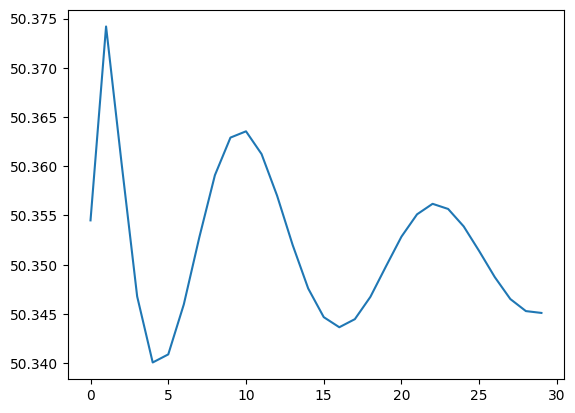

In [5]:
print(P_bisto)
plt.plot([k for k in range(30)], [b.detach() for b in biomass_list_bisto])

Comment trouver la meilleure matrice bistochastique ? Partir d'une matrice quelconque, ou alors d'une matrice de permutation

In [14]:
print(params, N)

{'N': 10, 'L': 0.1, 'H': 1, 'nb_colonnes_default': 50, 'D': 1e-05, 'T': 6, 'CFL': 0.95, 'u': [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1], 'I_s': 1500, 'epsilon': 4.6, 'k_d': 0.000299, 'k_r': 0.00048, 'k_h': 0.000364, 'tau': 6.849, 'sigma_H': 0.0029, 'theta': 1.0556e-06, 'I_star': np.float64(166.94501039780602), 'mu_max': np.float64(3.315108749636504e-05)} 10


In [10]:
params["N"] = 3
params["u"] = [0.1]*3
for k in range(4):
    #matrice quelconque
    P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_uniform_torch(3, nb_colonnes_default), T, params)
    print(P_bisto, biomass_list_bisto[-1])

obj: tensor(151.1908, grad_fn=<AddBackward0>) pen: tensor(0.2204, grad_fn=<SumBackward0>)
obj: tensor(151.1481, grad_fn=<AddBackward0>) pen: tensor(0.0436, grad_fn=<SumBackward0>)
obj: tensor(151.1004, grad_fn=<AddBackward0>) pen: tensor(0.0038, grad_fn=<SumBackward0>)
obj: tensor(151.0680, grad_fn=<AddBackward0>) pen: tensor(0.0606, grad_fn=<SumBackward0>)
obj: tensor(151.0656, grad_fn=<AddBackward0>) pen: tensor(0.0834, grad_fn=<SumBackward0>)
obj: tensor(151.0780, grad_fn=<AddBackward0>) pen: tensor(0.0613, grad_fn=<SumBackward0>)
obj: tensor(151.0942, grad_fn=<AddBackward0>) pen: tensor(0.0268, grad_fn=<SumBackward0>)
obj: tensor(151.1102, grad_fn=<AddBackward0>) pen: tensor(0.0041, grad_fn=<SumBackward0>)
obj: tensor(151.1221, grad_fn=<AddBackward0>) pen: tensor(0.0035, grad_fn=<SumBackward0>)
obj: tensor(151.1299, grad_fn=<AddBackward0>) pen: tensor(0.0200, grad_fn=<SumBackward0>)
obj: tensor(151.1347, grad_fn=<AddBackward0>) pen: tensor(0.0343, grad_fn=<SumBackward0>)
obj: tenso

In [5]:
#matrice quelconque
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_uniform_torch(N, nb_colonnes_default), T, params)

obj: tensor(503.7818, grad_fn=<AddBackward0>) pen: tensor(0.4652, grad_fn=<SumBackward0>)
obj: tensor(503.7549, grad_fn=<AddBackward0>) pen: tensor(0.0636, grad_fn=<SumBackward0>)
obj: tensor(503.7661, grad_fn=<AddBackward0>) pen: tensor(0.0495, grad_fn=<SumBackward0>)
obj: tensor(503.7816, grad_fn=<AddBackward0>) pen: tensor(0.1282, grad_fn=<SumBackward0>)
obj: tensor(503.7880, grad_fn=<AddBackward0>) pen: tensor(0.1773, grad_fn=<SumBackward0>)
obj: tensor(503.7834, grad_fn=<AddBackward0>) pen: tensor(0.1544, grad_fn=<SumBackward0>)
obj: tensor(503.7765, grad_fn=<AddBackward0>) pen: tensor(0.0933, grad_fn=<SumBackward0>)
obj: tensor(503.7747, grad_fn=<AddBackward0>) pen: tensor(0.0318, grad_fn=<SumBackward0>)
obj: tensor(503.7800, grad_fn=<AddBackward0>) pen: tensor(0.0028, grad_fn=<SumBackward0>)
obj: tensor(503.7889, grad_fn=<AddBackward0>) pen: tensor(0.0169, grad_fn=<SumBackward0>)
obj: tensor(503.7936, grad_fn=<AddBackward0>) pen: tensor(0.0503, grad_fn=<SumBackward0>)
obj: tenso

In [6]:
print(P_bisto) #second try

tensor([[0.1186, 0.0981, 0.0171, 0.0567, 0.0085, 0.0937, 0.0817, 0.2823, 0.1721,
         0.0631],
        [0.1868, 0.0941, 0.0778, 0.3414, 0.0450, 0.0177, 0.0669, 0.0955, 0.0491,
         0.0227],
        [0.1060, 0.0997, 0.0263, 0.0967, 0.0606, 0.0588, 0.0985, 0.1010, 0.2993,
         0.0455],
        [0.0929, 0.1151, 0.1100, 0.0901, 0.0234, 0.1828, 0.0379, 0.0229, 0.2263,
         0.0866],
        [0.0544, 0.3117, 0.0206, 0.1142, 0.0377, 0.0301, 0.0200, 0.1742, 0.0116,
         0.2150],
        [0.1036, 0.0707, 0.1620, 0.0540, 0.1405, 0.0440, 0.1684, 0.1067, 0.1279,
         0.0338],
        [0.1082, 0.0675, 0.0681, 0.0199, 0.0066, 0.2700, 0.2273, 0.0207, 0.0395,
         0.1511],
        [0.0795, 0.1023, 0.0469, 0.0927, 0.0218, 0.0294, 0.1045, 0.1268, 0.0321,
         0.3523],
        [0.0975, 0.0161, 0.1360, 0.0569, 0.5991, 0.0611, 0.0411, 0.0276, 0.0240,
         0.0243],
        [0.0526, 0.0248, 0.3353, 0.0774, 0.0569, 0.2124, 0.1536, 0.0424, 0.0180,
         0.0057]], grad_fn=<

In [ ]:
print(P_bisto) #first try

tensor([[0.0458, 0.2620, 0.0980, 0.1809, 0.0664, 0.0402, 0.0331, 0.0435, 0.0768,
         0.1699],
        [0.0115, 0.1891, 0.0922, 0.1632, 0.0937, 0.1320, 0.1822, 0.0445, 0.0373,
         0.0486],
        [0.0316, 0.1971, 0.0335, 0.0884, 0.1121, 0.0866, 0.0351, 0.0384, 0.3079,
         0.0515],
        [0.0159, 0.0674, 0.0933, 0.1510, 0.1349, 0.0411, 0.1318, 0.0547, 0.1017,
         0.2231],
        [0.4099, 0.0539, 0.0148, 0.0107, 0.0738, 0.1219, 0.0395, 0.2229, 0.0518,
         0.0234],
        [0.0197, 0.0976, 0.1988, 0.0457, 0.0776, 0.0920, 0.1033, 0.1491, 0.0272,
         0.1625],
        [0.0070, 0.0201, 0.0545, 0.1164, 0.0544, 0.2814, 0.3221, 0.0452, 0.0360,
         0.0459],
        [0.0363, 0.0101, 0.2214, 0.0507, 0.1082, 0.0898, 0.0250, 0.2182, 0.1912,
         0.0305],
        [0.1300, 0.0383, 0.1406, 0.1584, 0.0659, 0.0861, 0.1083, 0.0362, 0.0740,
         0.1509],
        [0.2922, 0.0643, 0.0529, 0.0344, 0.2130, 0.0288, 0.0197, 0.1473, 0.0960,
         0.0937]], grad_fn=<

In [13]:
print(P_bisto)

tensor([[0.1156, 0.1104, 0.0344, 0.0181, 0.0779, 0.2011, 0.0729, 0.3282, 0.0292,
         0.0110],
        [0.0126, 0.1539, 0.0153, 0.2588, 0.0171, 0.0670, 0.1168, 0.1302, 0.0875,
         0.1625],
        [0.1663, 0.0375, 0.0241, 0.0892, 0.2592, 0.0170, 0.0958, 0.0566, 0.1317,
         0.0791],
        [0.0372, 0.0202, 0.5708, 0.1360, 0.0340, 0.0282, 0.0190, 0.0352, 0.0328,
         0.0226],
        [0.0182, 0.0616, 0.0508, 0.0833, 0.0813, 0.0152, 0.2263, 0.1601, 0.2783,
         0.0525],
        [0.0645, 0.0474, 0.0976, 0.0118, 0.0819, 0.1911, 0.0902, 0.0265, 0.1437,
         0.2512],
        [0.4265, 0.0377, 0.0637, 0.0105, 0.0307, 0.1608, 0.0191, 0.0417, 0.0351,
         0.1648],
        [0.0259, 0.3856, 0.0160, 0.0284, 0.0602, 0.0496, 0.0788, 0.1247, 0.1892,
         0.0823],
        [0.0521, 0.0410, 0.1235, 0.2564, 0.0676, 0.1328, 0.2394, 0.0196, 0.0225,
         0.0683],
        [0.0810, 0.1047, 0.0037, 0.1076, 0.2900, 0.1372, 0.0416, 0.0772, 0.0500,
         0.1057]], grad_fn=<

avec plus d'itérations, car 30 ne suffisent pas.

In [ ]:
#matrice quelconque
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(N, nb_colonnes_default), T, params, 200)

obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(1.0207, grad_fn=<SumBackward0>)
obj: tensor(50.0080, grad_fn=<AddBackward0>) pen: tensor(0.3230, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.0717, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.0613, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.1429, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.2035, grad_fn=<SumBackward0>)
obj: tensor(50.0078, grad_fn=<AddBackward0>) pen: tensor(0.2103, grad_fn=<SumBackward0>)
obj: tensor(50.0078, grad_fn=<AddBackward0>) pen: tensor(0.1912, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.1701, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.1528, grad_fn=<SumBackward0>)
obj: tensor(50.0079, grad_fn=<AddBackward0>) pen: tensor(0.1327, grad_fn=<SumBackward0>)
obj: tensor(50.0079, 

In [ ]:
print(P_bisto)

NameError: name 'P_bisto' is not defined

In [10]:
print(P_bisto)

tensor([[0.1727, 0.0401, 0.1280, 0.1118, 0.0686, 0.0839, 0.0447, 0.2331, 0.0285,
         0.0885],
        [0.0422, 0.2675, 0.0660, 0.1765, 0.0297, 0.0281, 0.1194, 0.1010, 0.0907,
         0.0790],
        [0.2268, 0.0297, 0.1286, 0.0654, 0.0687, 0.0290, 0.2182, 0.0791, 0.1469,
         0.0075],
        [0.1335, 0.1178, 0.0531, 0.0894, 0.1766, 0.0053, 0.0866, 0.0164, 0.0864,
         0.2348],
        [0.2559, 0.0255, 0.3115, 0.0160, 0.0122, 0.0688, 0.0067, 0.1059, 0.1850,
         0.0123],
        [0.0238, 0.3348, 0.0341, 0.0567, 0.2197, 0.0715, 0.0415, 0.0387, 0.1417,
         0.0375],
        [0.0467, 0.0217, 0.0830, 0.3417, 0.0783, 0.0183, 0.2618, 0.0856, 0.0249,
         0.0380],
        [0.0410, 0.0510, 0.0688, 0.0451, 0.2185, 0.1392, 0.0301, 0.2752, 0.1097,
         0.0213],
        [0.0356, 0.0181, 0.0586, 0.0700, 0.1100, 0.5202, 0.0761, 0.0173, 0.0743,
         0.0198],
        [0.0218, 0.0936, 0.0683, 0.0274, 0.0177, 0.0357, 0.1148, 0.0476, 0.1119,
         0.4613]], grad_fn=<

puis en partant d'une matrice de permutation :

In [3]:
#matrice de permutation quelconque
M = [
    [0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0],
    [0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0],
    [0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
    [0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0],
    [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0],
    [0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0],
    [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0]
]

In [4]:
P_bisto, biomass_list_bisto = solve_bistochastique(X_ini_one_layer_torch(N, nb_colonnes_default), T, params, 100, 1000, 0.2, True, torch.tensor(M))

obj: tensor(50.3634, grad_fn=<AddBackward0>) pen: tensor(0., grad_fn=<SumBackward0>)
obj: tensor(50.3784, grad_fn=<AddBackward0>) pen: tensor(0.3363, grad_fn=<SumBackward0>)
obj: tensor(50.3674, grad_fn=<AddBackward0>) pen: tensor(0.0334, grad_fn=<SumBackward0>)
obj: tensor(50.3565, grad_fn=<AddBackward0>) pen: tensor(0.0768, grad_fn=<SumBackward0>)
obj: tensor(50.3520, grad_fn=<AddBackward0>) pen: tensor(0.1906, grad_fn=<SumBackward0>)
obj: tensor(50.3537, grad_fn=<AddBackward0>) pen: tensor(0.1372, grad_fn=<SumBackward0>)
obj: tensor(50.3585, grad_fn=<AddBackward0>) pen: tensor(0.0337, grad_fn=<SumBackward0>)
obj: tensor(50.3642, grad_fn=<AddBackward0>) pen: tensor(0.0027, grad_fn=<SumBackward0>)
obj: tensor(50.3687, grad_fn=<AddBackward0>) pen: tensor(0.0487, grad_fn=<SumBackward0>)
obj: tensor(50.3708, grad_fn=<AddBackward0>) pen: tensor(0.0928, grad_fn=<SumBackward0>)
obj: tensor(50.3704, grad_fn=<AddBackward0>) pen: tensor(0.0859, grad_fn=<SumBackward0>)
obj: tensor(50.3681, grad

KeyboardInterrupt: 

tensor([[0.0965, 0.0720, 0.0721, 0.2636, 0.0721, 0.0859, 0.0970, 0.0721, 0.0721,
         0.0970],
        [0.2633, 0.0720, 0.0720, 0.0970, 0.0720, 0.0858, 0.0970, 0.0720, 0.0720,
         0.0970],
        [0.0988, 0.0753, 0.0753, 0.0986, 0.0753, 0.2289, 0.0986, 0.0753, 0.0753,
         0.0986],
        [0.0695, 0.0948, 0.2576, 0.0694, 0.0948, 0.0856, 0.0694, 0.0948, 0.0948,
         0.0694],
        [0.0697, 0.0948, 0.0947, 0.0694, 0.0947, 0.0855, 0.0694, 0.2575, 0.0947,
         0.0694],
        [0.0696, 0.2576, 0.0947, 0.0694, 0.0947, 0.0855, 0.0694, 0.0947, 0.0947,
         0.0694],
        [0.0696, 0.0948, 0.0947, 0.0694, 0.2575, 0.0856, 0.0694, 0.0947, 0.0947,
         0.0694],
        [0.0696, 0.0948, 0.0948, 0.0694, 0.0948, 0.0856, 0.0694, 0.0948, 0.2576,
         0.0694],
        [0.0969, 0.0720, 0.0720, 0.0969, 0.0720, 0.0858, 0.2635, 0.0720, 0.0720,
         0.0969],
        [0.0966, 0.0720, 0.0720, 0.0970, 0.0721, 0.0859, 0.0970, 0.0721, 0.0721,
         0.2636]], grad_fn=<

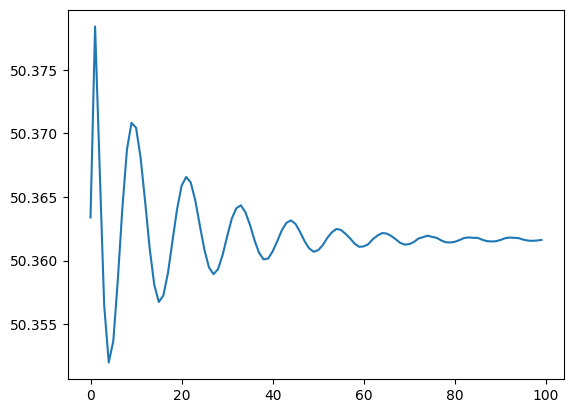

In [14]:
print(P_bisto)
plt.plot([k for k in range(100)], [b.detach() for b in biomass_list_bisto])